In [1]:
import scanpy as sc
import rapids_singlecell as rsc
import seaborn as sns
import numpy as np
import pandas as pd
from cuml.svm import SVC
from sklearn.preprocessing import LabelEncoder
from cuml.linear_model import LogisticRegression
import gcsfs
import pyarrow.dataset as ds
import os
import matplotlib.pyplot as plt

In [257]:
adata = sc.read_h5ad('./comb_integrated.h5ad')
adata.obs_names_make_unique()

/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [258]:
GCS_BASE_PATH = "gs://arc-scbasecount/2025-02-25/"
FEATURE_TYPE = "GeneFull_Ex50pAS"
TF_CHECKPOINT = "/data/cachris/tf_embeddings/checkpoints/tf_metazoa"
OUT_DIR = "./tf_out"
N_CHUNKS = 25

ALLOWED_ORGS = [
    "Mus musculus", "Homo sapiens", "Danio rerio", "Oryctolagus cuniculus",
    "Drosophila melanogaster", "Gallus gallus"
]


fs = gcsfs.GCSFileSystem()
species = pd.Series()
# path to metadata parquet files
gcs_path = "/".join([GCS_BASE_PATH.rstrip("/"), "metadata", FEATURE_TYPE])

# find sample_metadata.parquet files
files = fs.glob("/".join([gcs_path.rstrip("/"), "**"]))
files = [f for f in files if os.path.basename(f) == "sample_metadata.parquet"]

embryos = []
for f in files:
    meta = ds.dataset(f, filesystem=fs, format="parquet").to_table().to_pandas()
    meta = meta[meta['srx_accession'].isin(adata.obs['SRX_accession'])]
    species= pd.concat([species, meta])
adata.obs = pd.merge(adata.obs, species, left_on='SRX_accession', right_on = 'srx_accession', how = 'left')


/data/cachris/miniconda3/envs/rapids/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.


# transfer labels from the Human Fetal Atlas subset of the data using logreg

In [259]:
def label_transfer(adata, obs):

    labeled_mask = (adata.obs[obs] != 'na') & (adata.obs[obs] != '')

    unlabeled_mask = ~labeled_mask
    X_train = adata.X[labeled_mask]
    X_pred  = adata.X[unlabeled_mask]
    y_train = adata.obs.loc[labeled_mask, obs].values
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    clf = LogisticRegression(max_iter=200)
    clf.fit(X_train, y_train_enc)
    y_pred_enc = clf.predict(adata.X)
    proba = clf.predict_proba(adata.X)
    proba = pd.DataFrame(proba)
    proba.columns = le.inverse_transform(range(0,proba.shape[1]))
    proba.index = adata.obs_names
    y_pred = le.inverse_transform(y_pred_enc)
    adata.obs[obs + '_pred'] = y_pred
    adata.obsm[obs + '_pred_prob'] = proba

In [260]:
rsc.get.anndata_to_CPU(adata)

In [261]:
adata.obs['Development_day'] = adata.obs['Development_day'].astype(str)
label_transfer(adata, 'Organ')
label_transfer(adata, 'Development_day')
label_transfer(adata, 'Main_cluster_name')
adata.obs['main_cluster_confidence'] = adata.obsm['Main_cluster_name_pred_prob'].max(axis = 1)

[2026-01-30 21:46:36.201] [CUML] [warning] L-BFGS: max iterations reached
[2026-01-30 21:46:36.201] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
[2026-01-30 21:46:40.476] [CUML] [warning] L-BFGS: max iterations reached
[2026-01-30 21:46:40.476] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
[2026-01-30 21:46:44.188] [CUML] [warning] L-BFGS: max iterations reached
[2026-01-30 21:46:44.188] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.


In [263]:
adata.obs

,SRX_accession,assay,barcode,cell_id,Unnamed: 0,Exon_reads,Intron_reads,All_reads,RT_group,Organ,...,organism,tissue,disease,perturbation,cell_line,czi_collection_id,czi_collection_name,Organ_pred,Development_day_pred,Main_cluster_name_pred
0,SRX19731088,na,AAAGAACTCTTTGCTA,na,na,na,na,na,na,na,...,Danio rerio,embryo,unsure,unsure,Kdrl positive cells from Tg(kdrl:EGFP) zebrafi...,None,None,Cerebellum,125.0,Purkinje neurons
1,SRX19731088,na,AAAGGATCAGTCTCTC,na,na,na,na,na,na,na,...,Danio rerio,embryo,unsure,unsure,Kdrl positive cells from Tg(kdrl:EGFP) zebrafi...,None,None,Pancreas,117.0,Lymphoid cells
2,SRX19731088,na,AAAGGGCGTGCATCTA,na,na,na,na,na,na,na,...,Danio rerio,embryo,unsure,unsure,Kdrl positive cells from Tg(kdrl:EGFP) zebrafi...,None,None,Cerebellum,125.0,Purkinje neurons
3,SRX19731088,na,AAAGTGAAGCTCACTA,na,na,na,na,na,na,na,...,Danio rerio,embryo,unsure,unsure,Kdrl positive cells from Tg(kdrl:EGFP) zebrafi...,None,None,Spleen,115.0,Purkinje neurons
4,SRX19731088,na,AAAGTGAGTGTCCATA,na,na,na,na,na,na,na,...,Danio rerio,embryo,unsure,unsure,Kdrl positive cells from Tg(kdrl:EGFP) zebrafi...,None,None,Pancreas,117.0,Astrocytes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10220844,na,26,na,exp3-human-475well.TTGGTTAAGTCTCGTCTAGG,4996841,187,69,312,Thymus_H27431,Thymus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spleen,115.0,STC2_TLX1 positive cells
10220845,na,26,na,exp3-human-476well.GGCTTACTTTGGAAGTACC,4996842,215,127,395,Thymus_H27431,Thymus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spleen,115.0,STC2_TLX1 positive cells
10220846,na,26,na,exp3-human-476well.TCCAAGTTATATCCATGACT,4996843,104,231,389,Thymus_H27471,Thymus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thymus,113.0,Thymocytes
10220847,na,26,na,exp3-human-477well.CTATCTCCTAGTCCGCGGA,4996844,222,107,404,Thymus_H27431,Thymus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spleen,115.0,STC2_TLX1 positive cells


# Not a true cross validation, but sanity check the labels on the ground reference data

<Axes: xlabel='Organ_pred', ylabel='Organ'>

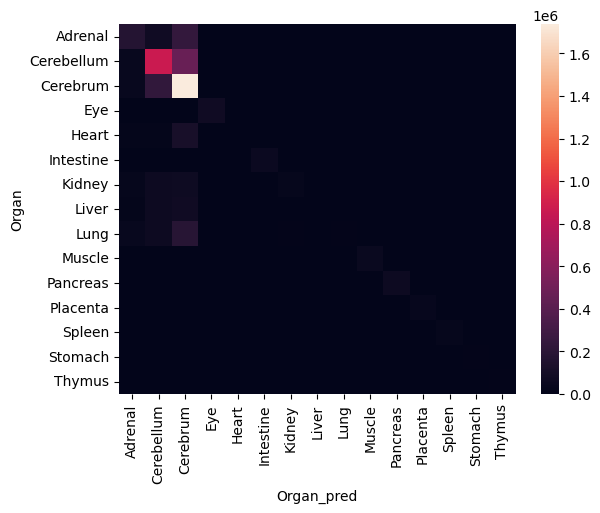

In [262]:
ref
sns.heatmap(pd.crosstab(adata[adata.obs['Organ'] != 'na'].obs['Organ'], adata[adata.obs['Organ'] != 'na'].obs['Organ_pred']))


# Make a couple of UMAPS

In [265]:
import rapids_singlecell as rsc

In [266]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.neighbors(adata)
rsc.tl.umap(adata)

With the rapids UMAP implementation, there is an error where a couple cells end up as distant outliers.  for the sake of visualization, we remove them

In [267]:
import numpy as np

um = adata.obsm["X_umap"]
u1, u2 = um[:, 0], um[:, 1]

# robust center
c1, c2 = np.median(u1), np.median(u2)
r = np.sqrt((u1 - c1)**2 + (u2 - c2)**2)

keep_quantile = 0.9999   # keep 99.5% closest-to-center; try 0.99 if needed
thr = np.quantile(r, keep_quantile)

keep = r <= thr
adata_f = adata[keep].copy()

print("kept cells:", adata_f.n_obs, "removed:", (~keep).sum())

kept cells: 10219827 removed: 1022


KeyError: 'main_cluster_confidence'

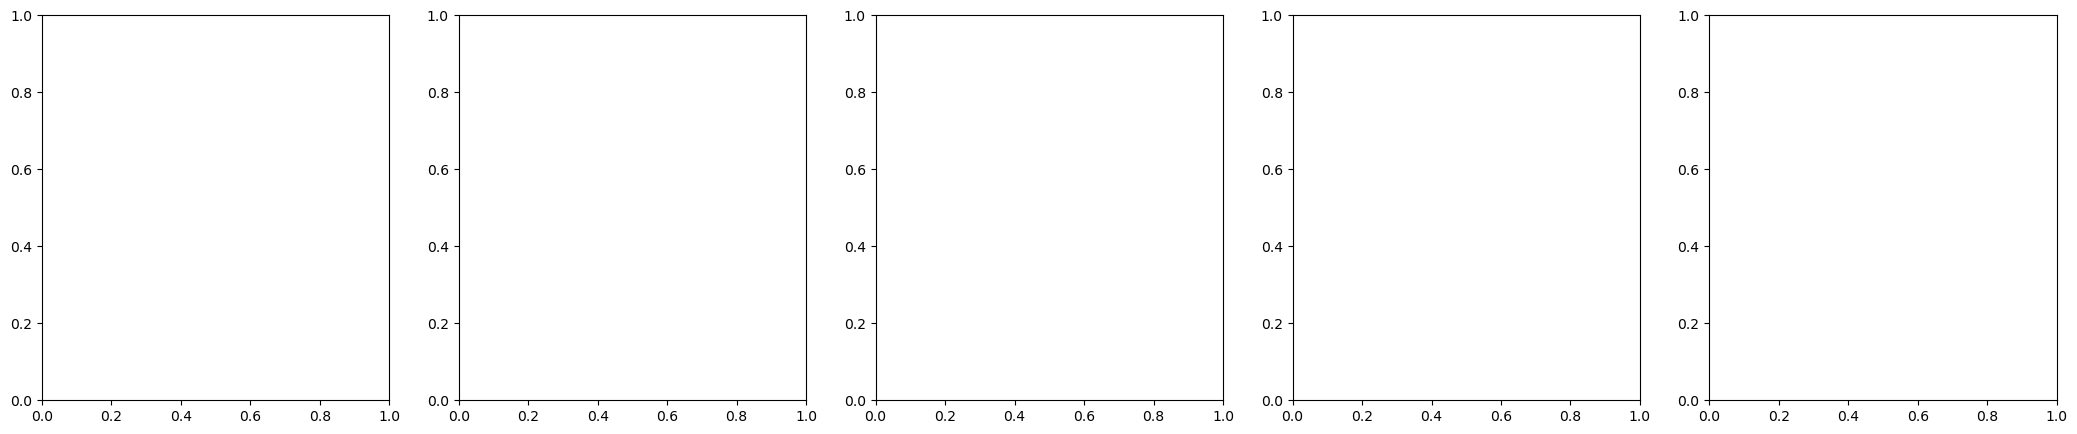

In [268]:
import matplotlib.pyplot as plt
import scanpy as sc
import rapids_singlecell as rsc

species_list = adata_f.obs['organism'].unique()[:-1]
n = len(species_list)

fig, axes = plt.subplots(
    1, n,
    figsize=(5 * n +1, 5),
    squeeze=False
)

for i, species in enumerate(species_list):
    
    ax = axes[0, i]

    mm = adata_f[adata_f.obs['organism'] == species].copy()
    
    # Move to GPU + compute UMAP
    rsc.get.anndata_to_GPU(mm)
    rsc.tl.umap(mm)

    # Subset *after* UMAP
    mm_plot = mm[mm.obs['main_cluster_confidence'] > 0.99]
    if i == len(species_list) -1:
        sc.pl.umap(
            mm_plot, color = 'Main_cluster_name_pred',
            ax=ax,
            show=False,
            title=str(species),
            frameon=True
        )
    else:
        sc.pl.umap(
            mm_plot, color = 'Main_cluster_name_pred',
            ax=ax,
            show=False,
            title=str(species),
            frameon=True, legend_loc = 'none'
        )

    del mm
plt.savefig('embryo_umap.pdf')
plt.savefig('embryo_umap.png')
plt.tight_layout()
plt.show()


/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'SRX_accession' as categorical
/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'Development_day' as categorical
/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'Organ_pred' as categorical
/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'Development

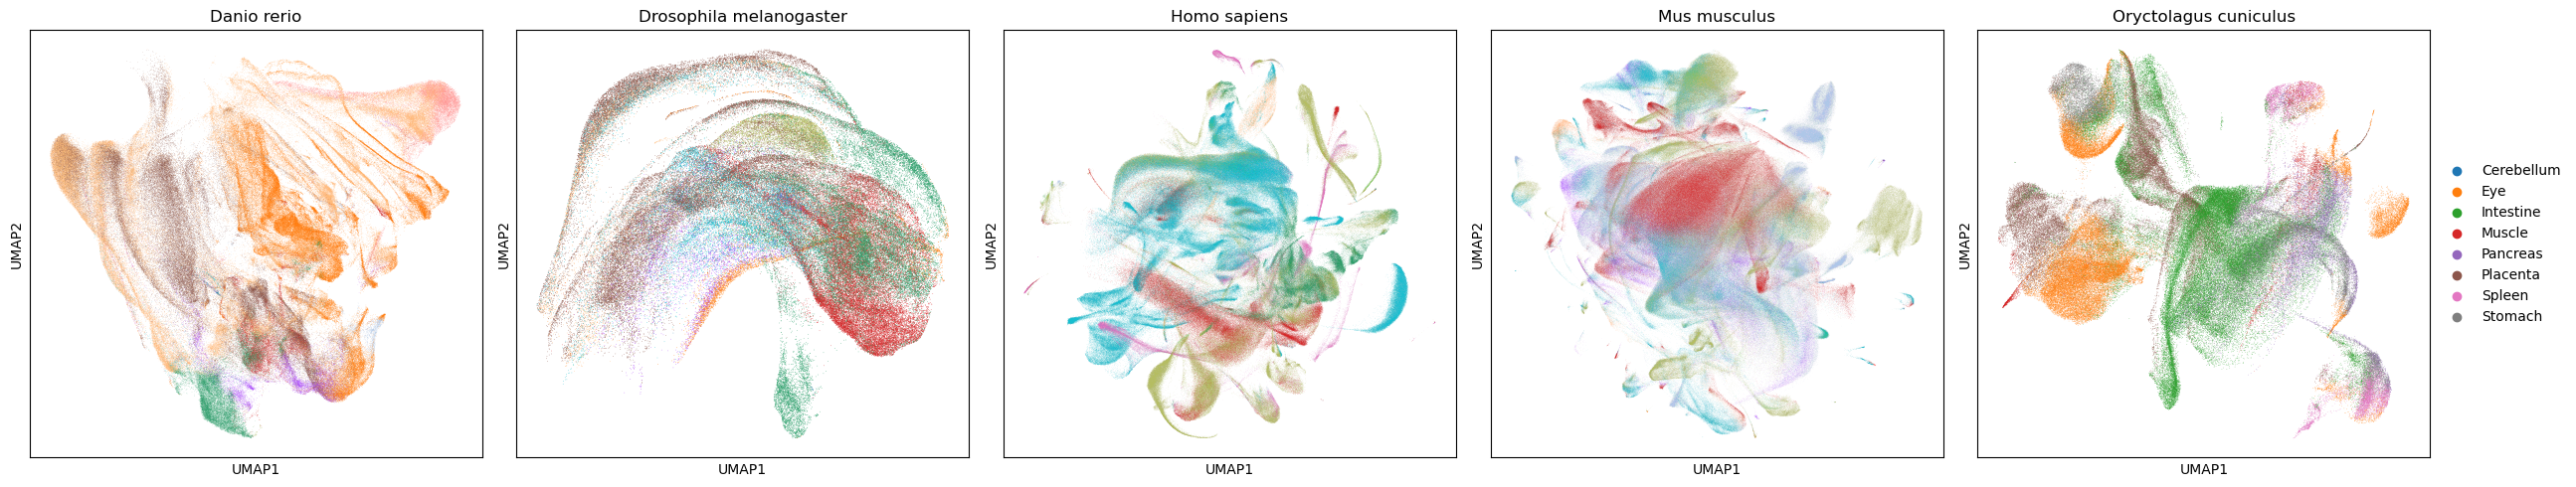

In [ ]:
import matplotlib.pyplot as plt
import scanpy as sc
import rapids_singlecell as rsc

species_list = adata.obs['organism'].unique()[:-1]
n = len(species_list)

fig, axes = plt.subplots(
    1, n,
    figsize=(5 * n +1, 5),
    squeeze=False
)

for i, species in enumerate(species_list):
    
    ax = axes[0, i]

    mm = adata_f[adata_f.obs['organism'] == species].copy()
    
    # Move to GPU + compute UMAP
    rsc.get.anndata_to_GPU(mm)
    rsc.tl.umap(mm)

    # Subset *after* UMAP
    mm_plot = mm[mm.obs['main_cluster_confidence'] > 0.99]
    if i == len(species_list) -1:
        sc.pl.umap(
            mm_plot, color = 'Organ_pred',
            ax=ax,
            show=False,
            title=str(species),
            frameon=True
        )
    else:
        sc.pl.umap(
            mm_plot, color = 'Organ_pred',
            ax=ax,
            show=False,
            title=str(species),
            frameon=True, legend_loc = 'none'
        )
    del mm

plt.tight_layout()
plt.show()


In [273]:
ct.sum()

organism
Danio rerio                1.0
Drosophila melanogaster    1.0
Homo sapiens               1.0
Mus musculus               1.0
Oryctolagus cuniculus      1.0
dtype: float64

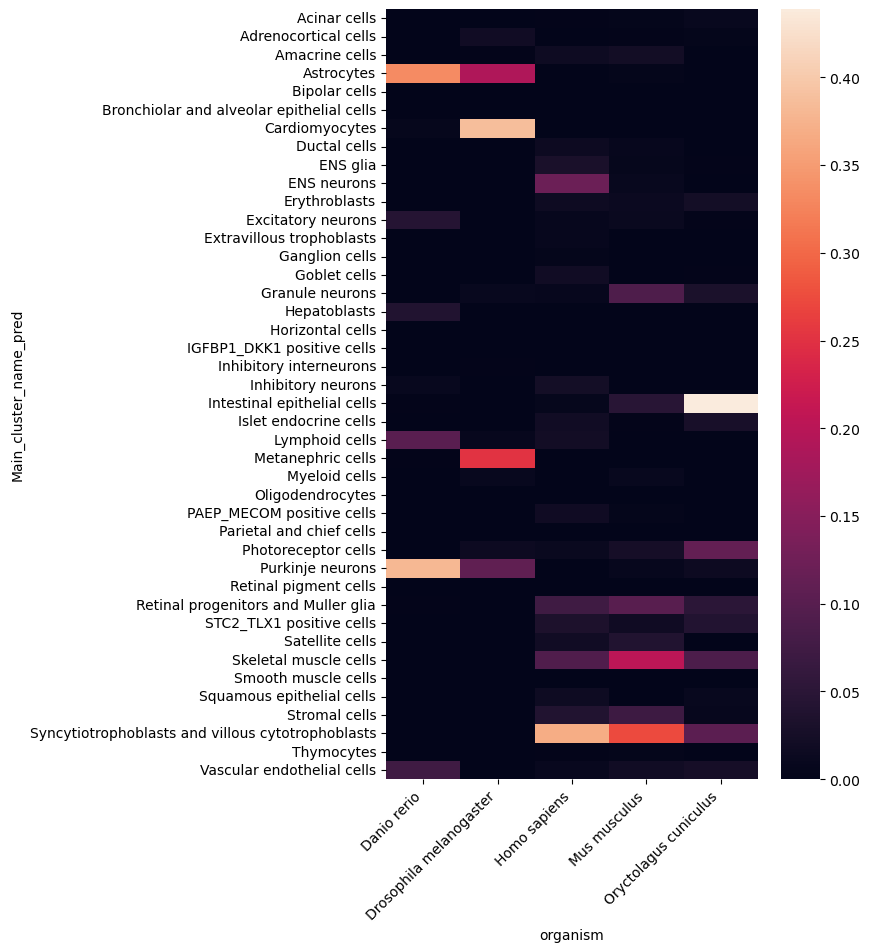

In [288]:
import matplotlib.pyplot as plt
ct = pd.crosstab(adata.obs['Main_cluster_name_pred'], adata.obs['organism'])
ct = ct.div(ct.sum(axis = 0), axis = 1)
plt.figure(figsize=(6,10))

sns.heatmap(ct)
plt.xticks(rotation=45,ha="right")
plt.savefig('species_organism_heatmap.png', bbox_inches="tight")
plt.savefig('species_organism_heatmap.pdf', bbox_inches="tight")

# save labels 

In [ ]:
adata.obs.to_parquet('embryos_labled.pq')

/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/pandas/io/parquet.py:191: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)


In [114]:
labels = pd.read_parquet('./embryos_labled.pq')

In [4]:
ct = pd.crosstab(labels[labels['organism'] == 'Oryctolagus cuniculus']['SRX_accession'], labels[labels['organism'] == 'Oryctolagus cuniculus']['Main_cluster_name_pred'])
ct = ct.loc[ct.sum(axis = 1) > 5000, :]
ct.var(axis = 1).sort_values()
srx= ct.var(axis = 1).sort_values().index[0]

In [173]:
fs = gcsfs.GCSFileSystem()
infile = f'gs://arc-scbasecount/2025-02-25/h5ad/GeneFull_Ex50pAS/Oryctolagus_cuniculus/{srx}.h5ad'

local_in = os.path.join("input.h5ad")


# copy from GCS
fs.get(infile, local_in)
zebrafish =  sc.read_h5ad(local_in)

In [174]:
infile

'gs://arc-scbasecount/2025-02-25/h5ad/GeneFull_Ex50pAS/Oryctolagus_cuniculus/ERX9511926.h5ad'

In [176]:
labels = labels[labels['SRX_accession'] == srx]

In [178]:
zebrafish.obs = zebrafish.obs.merge(labels,left_index=True, right_on='barcode')

In [179]:
rsc.get.anndata_to_GPU(zebrafish)
rsc.pp.calculate_qc_metrics(zebrafish)

... storing 'SRX_accession_y' as categorical
... storing 'Development_day' as categorical
... storing 'Organ_pred' as categorical
... storing 'Development_day_pred' as categorical
... storing 'Main_cluster_name_pred' as categorical
... storing 'srx_accession' as categorical
... storing 'file_path' as categorical
... storing 'lib_prep' as categorical
... storing 'tech_10x' as categorical
... storing 'cell_prep' as categorical
... storing 'organism' as categorical
... storing 'tissue' as categorical
... storing 'disease' as categorical
... storing 'perturbation' as categorical
... storing 'cell_line' as categorical


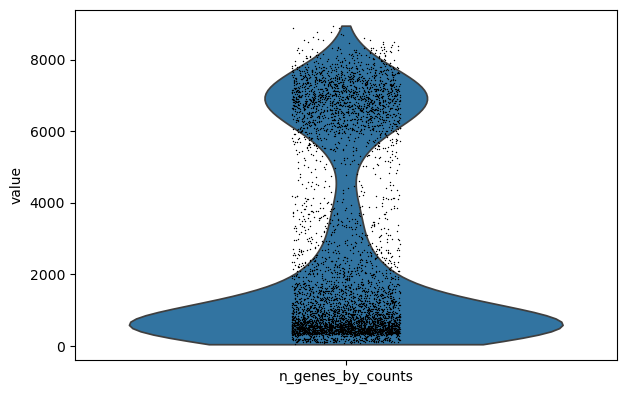

In [180]:
sc.pl.violin(zebrafish, 'n_genes_by_counts')

In [181]:
rsc.pp.normalize_total(zebrafish)
rsc.pp.log1p(zebrafish)
rsc.pp.filter_genes(zebrafish, min_cells = 10)
rsc.pp.filter_cells(zebrafish, min_genes = 50)
rsc.pp.pca(zebrafish)
rsc.pp.neighbors(zebrafish)
rsc.tl.umap(zebrafish)

filtered out 8226 genes that are detected in less than 10 cells
filtered out 1 cells that have less than 50 genes expressed


In [182]:
rsc.tl.leiden(zebrafish, resolution = 0.2)

In [183]:
zebrafish.var_names = zebrafish.var['gene_symbols']

/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:854: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['GOLM1', 'ENSOCUG00000031223', 'ENSOCUG00000036469', 'ENSOCUG00000036117', 'JHY']

    Inferred to be: categorical



KeyError: 'Could not find key dpt_pseudotime in .var_names or .obs.columns.'

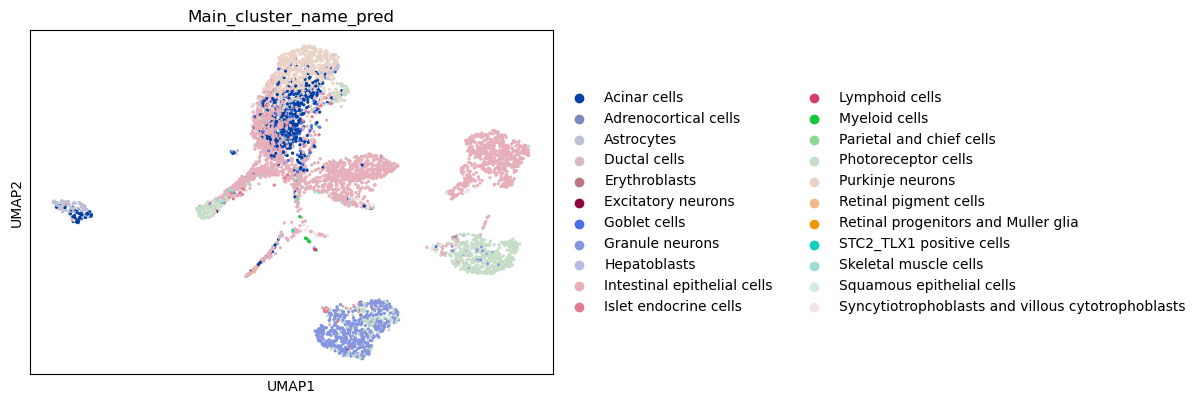

In [184]:
sc.pl.umap(zebrafish, color =['Main_cluster_name_pred', 'dpt_pseudotime','Development_day_pred'], ncols=1)

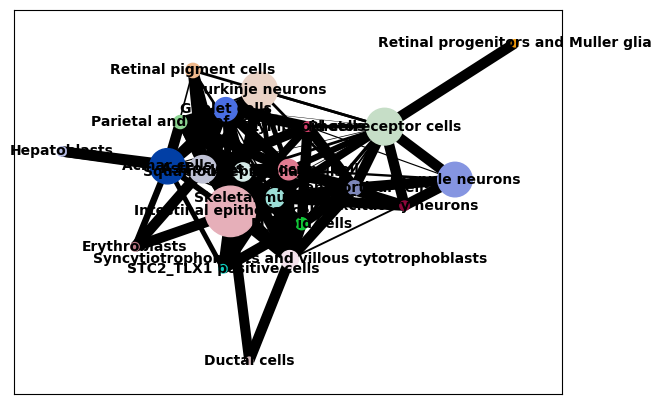

In [185]:
rsc.tl.draw_graph(zebrafish)
sc.tl.paga(zebrafish, 'Main_cluster_name_pred')
sc.pl.paga(zebrafish, threshold=0.03, show=False)
zebrafish.uns["iroot"] = np.flatnonzero(zebrafish.obs['Main_cluster_name_pred'] == "Erythroblasts")[0]
sc.tl.dpt(zebrafish)

In [186]:
rsc.get.anndata_to_CPU(zebrafish)

In [187]:
top_groups = zebrafish.obs['Main_cluster_name_pred'].value_counts().sort_values().tail(11)
sub = zebrafish[zebrafish.obs['Main_cluster_name_pred'].isin(top_groups)].copy()

/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [188]:
top_set

{'Acinar cells',
 'Astrocytes',
 'Goblet cells',
 'Granule neurons',
 'Intestinal epithelial cells',
 'Islet endocrine cells',
 'Photoreceptor cells',
 'Purkinje neurons',
 'Skeletal muscle cells',
 'Squamous epithelial cells',
 'Syncytiotrophoblasts and villous cytotrophoblasts'}

2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsi

<Axes: >

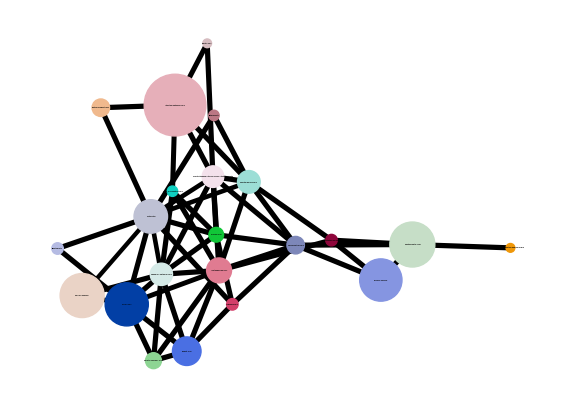

In [189]:
sc.pl.paga(
    zebrafish,
    threshold=0.8,
    show=False,
    frameon=False,
    node_size_scale=1.5,
    edge_width_scale=0.5, fontsize=0
)

2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
2026-01-30 21:14:33 | [INFO] Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsi

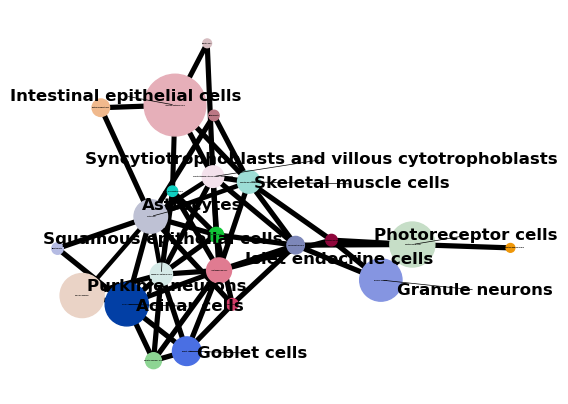

In [190]:
top_groups = (
    zebrafish.obs["Main_cluster_name_pred"]
    .value_counts()
    .sort_values()
    .tail(11)
)

top_set = set(top_groups.index)

sc.pl.paga(
    zebrafish,
    threshold=0.8,
    show=False,
    frameon=False,
    node_size_scale=1.5,
    edge_width_scale=0.5, fontsize=0
)

pos = zebrafish.uns["paga"]["pos"]
labels = zebrafish.obs["Main_cluster_name_pred"].cat.categories

from adjustText import adjust_text
import matplotlib.pyplot as plt

ax = plt.gca()
texts = []

for (x, y), label in zip(pos, labels):
    if label not in top_set:
        continue   # 🔑 skip small clusters

    texts.append(
        ax.text(
            x,
            y,
            label,
            fontsize=12,
            weight="bold",
            ha="center",
            va="center"
        )
    )

adjust_text(
    texts,
    ax=ax,
    expand_points=(1.3, 1.3),
    expand_text=(1.2, 1.2),
    force_text=0.5,
    force_points=0.5,
    arrowprops=dict(arrowstyle="-", lw=0.5)
)

plt.show()


In [191]:
zebrafish.obs['Main_cluster_name_pred'].value_counts()

Main_cluster_name_pred
Intestinal epithelial cells                          2478
Photoreceptor cells                                   700
Purkinje neurons                                      643
Acinar cells                                          592
Granule neurons                                       547
Astrocytes                                            215
Goblet cells                                          114
Islet endocrine cells                                  66
Skeletal muscle cells                                  45
Squamous epithelial cells                              42
Syncytiotrophoblasts and villous cytotrophoblasts      37
Retinal pigment cells                                  16
Adrenocortical cells                                   16
Parietal and chief cells                               11
Myeloid cells                                           8
Lymphoid cells                                          3
Excitatory neurons                               

/tmp/ipykernel_246939/2400820932.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


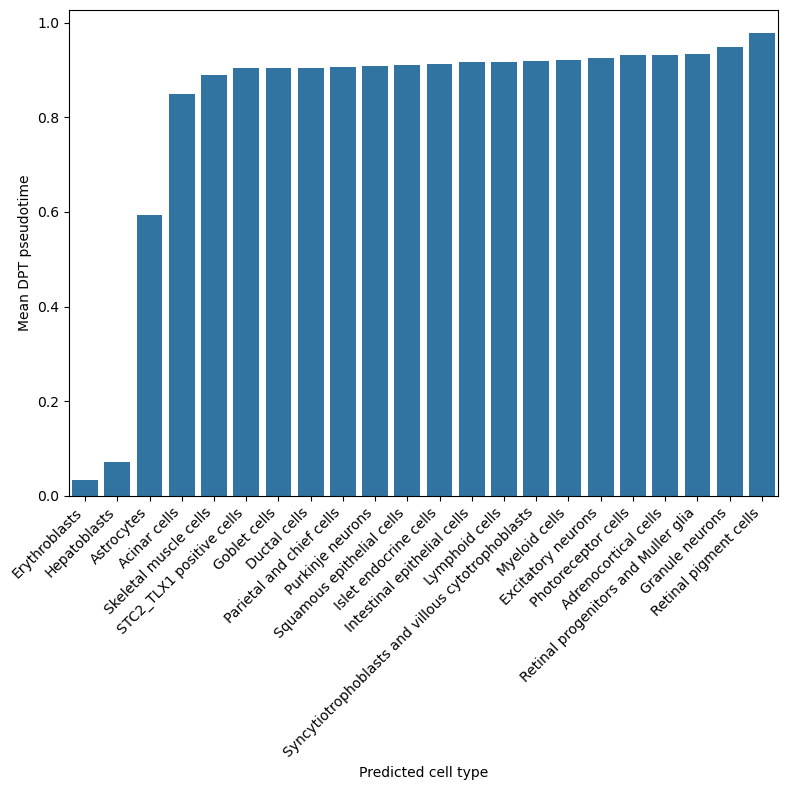

In [192]:
import matplotlib.pyplot as plt
import seaborn as sns

# compute means and sort
means = (
    zebrafish.obs
    .groupby("Main_cluster_name_pred")["dpt_pseudotime"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 8))

sns.barplot(
    x=means.index,
    y=means.values,
    order=means.index   # <-- enforce order
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean DPT pseudotime")
plt.xlabel("Predicted cell type")
plt.tight_layout()
plt.savefig('Rabit_cell_types_predicted_time.png')
plt.show()


<Axes: >

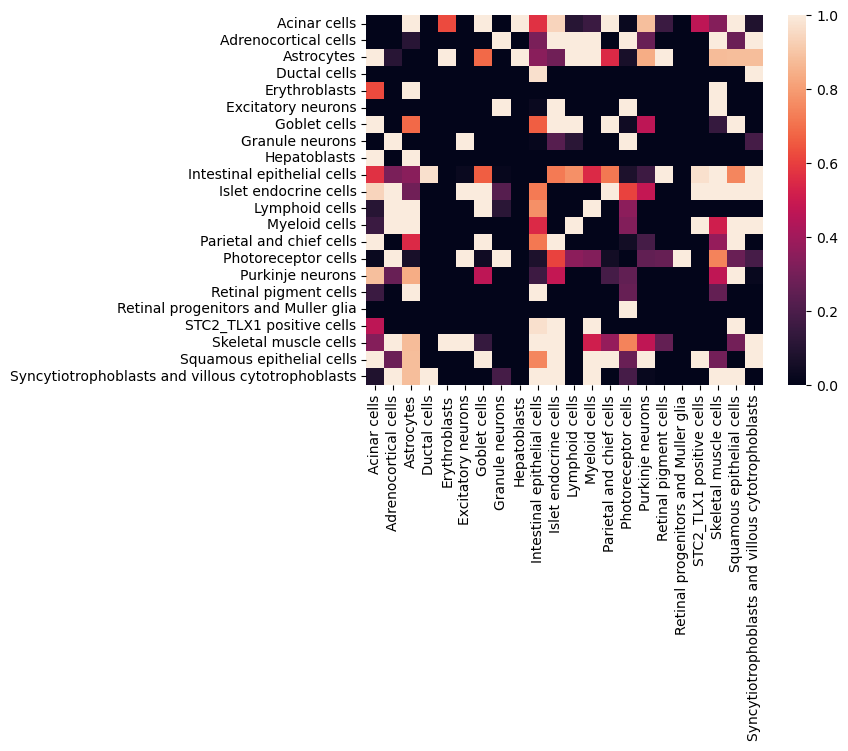

In [193]:
connections = pd.DataFrame(zebrafish.uns['paga']['connectivities'].toarray())
connections.index = zebrafish.obs['Main_cluster_name_pred'].cat.categories
connections.columns = zebrafish.obs['Main_cluster_name_pred'].cat.categories
sns.heatmap(connections)

KeyError: 'Could not find key main_cluster_confidence in .var_names or .obs.columns.'

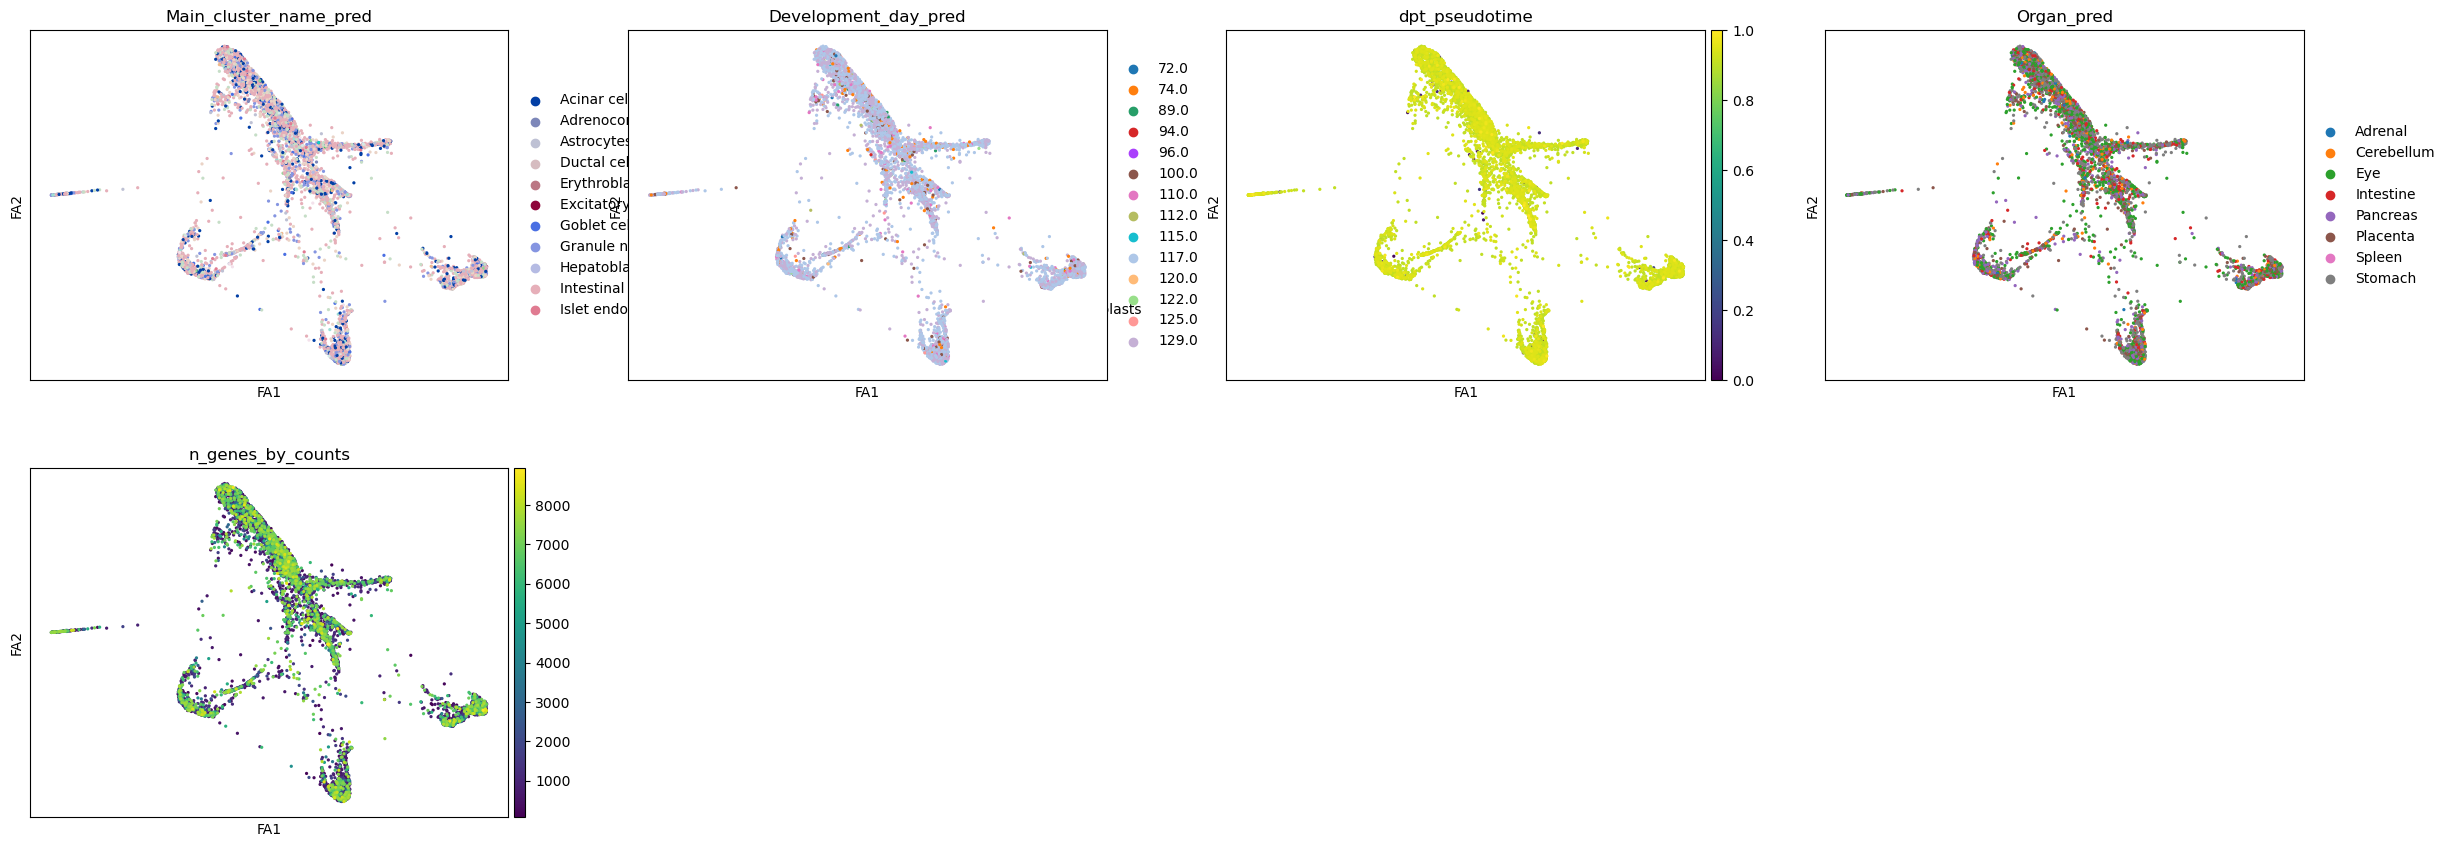

In [194]:
sc.pl.draw_graph(zebrafish,color  =['Main_cluster_name_pred','Development_day_pred', 'dpt_pseudotime','Organ_pred', 'n_genes_by_counts','main_cluster_confidence'])

In [ ]:
rsc.tl.rank_genes_groups_logreg(zebrafish, 'Organ_pred')

[2026-01-14 18:56:03.890] [CUML] [warning] L-BFGS: max iterations reached
[2026-01-14 18:56:03.890] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.


In [ ]:
rsc.get.anndata_to_CPU(zebrafish)

<Axes: xlabel='Organ_pred', ylabel='leiden'>

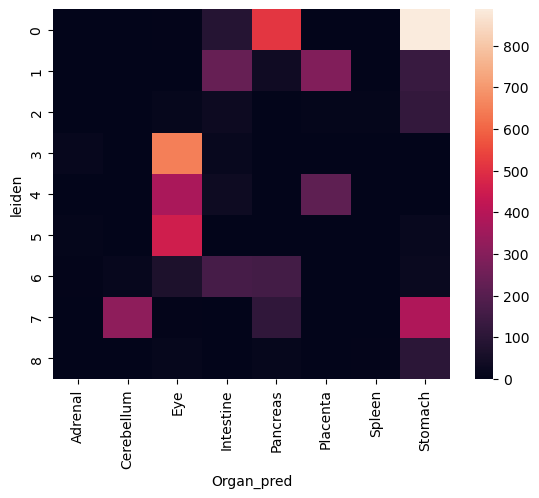

In [ ]:
sns.heatmap(pd.crosstab(zebrafish.obs['leiden'], zebrafish.obs['Organ_pred']))

In [ ]:
zebrafish.var_names = zebrafish.var_names.astype(str)
zebrafish.var_names_make_unique()

In [ ]:
sc.pl.scatter(zebrafish, y = 'AKAP9', x = 'dpt_pseudotime')

ValueError: `x`, `y`, and potential `color` inputs must all come from either `.obs` or `.var`

In [230]:
qc[1]

,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
gene_symbols,,,,,,
GOLM1,0,0.000000,0.000000,100.000000,0.000000,0.000000
ENSOCUG00000031223,2,0.005375,0.005361,94.594595,0.198875,0.181383
ENSOCUG00000036469,0,0.000000,0.000000,100.000000,0.000000,0.000000
ENSOCUG00000036117,0,0.000000,0.000000,100.000000,0.000000,0.000000
JHY,1,0.003614,0.003607,97.297297,0.133708,0.125494
...,...,...,...,...,...,...
ENSOCUG00000030996,0,0.000000,0.000000,100.000000,0.000000,0.000000
ENSOCUG00000035560,19,0.492303,0.400321,48.648649,18.215212,2.955702
ENSOCUG00000032298,37,3.539849,1.512894,0.000000,130.974442,4.882608


In [226]:
zebrafish

AnnData object with n_obs × n_vars = 5543 × 18115
    obs: 'gene_count', 'umi_count', 'SRX_accession_x', 'SRX_accession_y', 'assay', 'barcode', 'cell_id', 'Unnamed: 0', 'Exon_reads', 'Intron_reads', 'All_reads', 'RT_group', 'Organ', 'Fetus_id', 'Development_day', 'Sex', 'Batch', 'Main_cluster_umap_1', 'Main_cluster_umap_2', 'Main_cluster_name', 'Assay', 'Organ_cell_lineage', 'Experiment_batch', 'Organ_pred', 'Development_day_pred', 'Main_cluster_name_pred', '0', 'entrez_id', 'srx_accession', 'file_path', 'obs_count', 'lib_prep', 'tech_10x', 'cell_prep', 'organism', 'tissue', 'disease', 'perturbation', 'cell_line', 'czi_collection_id', 'czi_collection_name', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'leiden', 'dpt_pseudotime'
    var: 'gene_symbols', 'feature_types', 'n_cells_by_counts', 'total_counts', 'mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'log1p_mean_counts', 'n_counts', 'n_cells'
    uns: 'log1

In [241]:
bad_genes = zebrafish[zebrafish.obs['Main_cluster_name_pred'] == 'Syncytiotrophoblasts and villous cytotrophoblasts'].copy()
qc = sc.pp.calculate_qc_metrics(bad_genes)
print(bad_genes)
bad_genes_list = list(qc[1][qc[1]['n_cells_by_counts'] < 2].index)
bad_genes = zebrafish[zebrafish.obs['Main_cluster_name_pred'] == 'Intestinal epithelial cells'].copy()
qc = sc.pp.calculate_qc_metrics(bad_genes)
print(bad_genes)
bad_genes = list(qc[1][qc[1]['n_cells_by_counts'] < 2].index)
bad_genes_list.extend(bad_genes)

AnnData object with n_obs × n_vars = 37 × 18115
    obs: 'gene_count', 'umi_count', 'SRX_accession_x', 'SRX_accession_y', 'assay', 'barcode', 'cell_id', 'Unnamed: 0', 'Exon_reads', 'Intron_reads', 'All_reads', 'RT_group', 'Organ', 'Fetus_id', 'Development_day', 'Sex', 'Batch', 'Main_cluster_umap_1', 'Main_cluster_umap_2', 'Main_cluster_name', 'Assay', 'Organ_cell_lineage', 'Experiment_batch', 'Organ_pred', 'Development_day_pred', 'Main_cluster_name_pred', '0', 'entrez_id', 'srx_accession', 'file_path', 'obs_count', 'lib_prep', 'tech_10x', 'cell_prep', 'organism', 'tissue', 'disease', 'perturbation', 'cell_line', 'czi_collection_id', 'czi_collection_name', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'leiden', 'dpt_pseudotime'
    var: 'gene_symbols', 'feature_types', 'n_cells_by_counts', 'total_counts', 'mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'log1p_mean_counts', 'n_counts', 'n_cells'
    uns: 'log1p'

/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [210]:
zebrafish = zebrafish[~zebrafish.obs['Main_cluster_name_pred'].isin(['Retinal progenitors and Muller glia', 'Ductal cells'])]
rsc.get.anndata_to_CPU(zebrafish)
sc.tl.rank_genes_groups(zebrafish, groupby='Main_cluster_name_pred', reference='Syncytiotrophoblasts and villous cytotrophoblasts')

/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/scanpy/get/get.py:462: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [211]:
degs = sc.get.rank_genes_groups_df(zebrafish, None)

In [212]:
degs = degs[degs['group'] =='Intestinal epithelial cells' ].sort_values('pvals')

In [233]:
degs

,group,names,scores,logfoldchanges,pvals,pvals_adj,label,log_p
144928,Intestinal epithelial cells,PAPPA,13.844087,3.518440,1.203201e-22,4.191535e-20,None,21.919662
144949,Intestinal epithelial cells,ENSOCUG00000022009,10.947116,3.262272,2.712500e-19,6.551591e-17,None,18.566630
144974,Intestinal epithelial cells,TOX4,9.976878,3.175297,1.553231e-17,3.091954e-15,None,16.808764
144951,Intestinal epithelial cells,GPX2,10.905188,3.646526,2.935652e-17,5.597826e-15,None,16.532295
144975,Intestinal epithelial cells,ENSOCUG00000008745,9.974903,3.448254,4.877571e-16,7.960109e-14,None,15.311796
...,...,...,...,...,...,...,...,...
154565,Intestinal epithelial cells,ENSOCUG00000017030,0.001663,0.001446,9.986814e-01,1.000000e+00,None,0.000573
154566,Intestinal epithelial cells,PAFAH1B1,0.001536,0.000579,9.987826e-01,1.000000e+00,None,0.000529
154710,Intestinal epithelial cells,ENSOCUG00000001224,-0.000731,-0.000672,9.994204e-01,1.000000e+00,None,0.000252
154568,Intestinal epithelial cells,GOLIM4,0.000130,0.000075,9.998970e-01,1.000000e+00,None,0.000045


In [242]:
degs = degs[~degs['names'].isin(bad_genes_list)]

In [243]:
degs['label'] = None
degs.loc[(degs['pvals_adj'] < 1) & (np.abs(degs['logfoldchanges']) > 10), 'label'] = degs.loc[(degs['pvals_adj'] < 1) & (np.abs(degs['logfoldchanges']) > 10), 'names']

/tmp/ipykernel_246939/2997758206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [244]:
import gseapy as gp

/tmp/ipykernel_246939/1721510951.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_246939/1721510951.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/data/cachris/miniconda3/envs/rapids/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_label : Removed 9055 rows containing missing values.


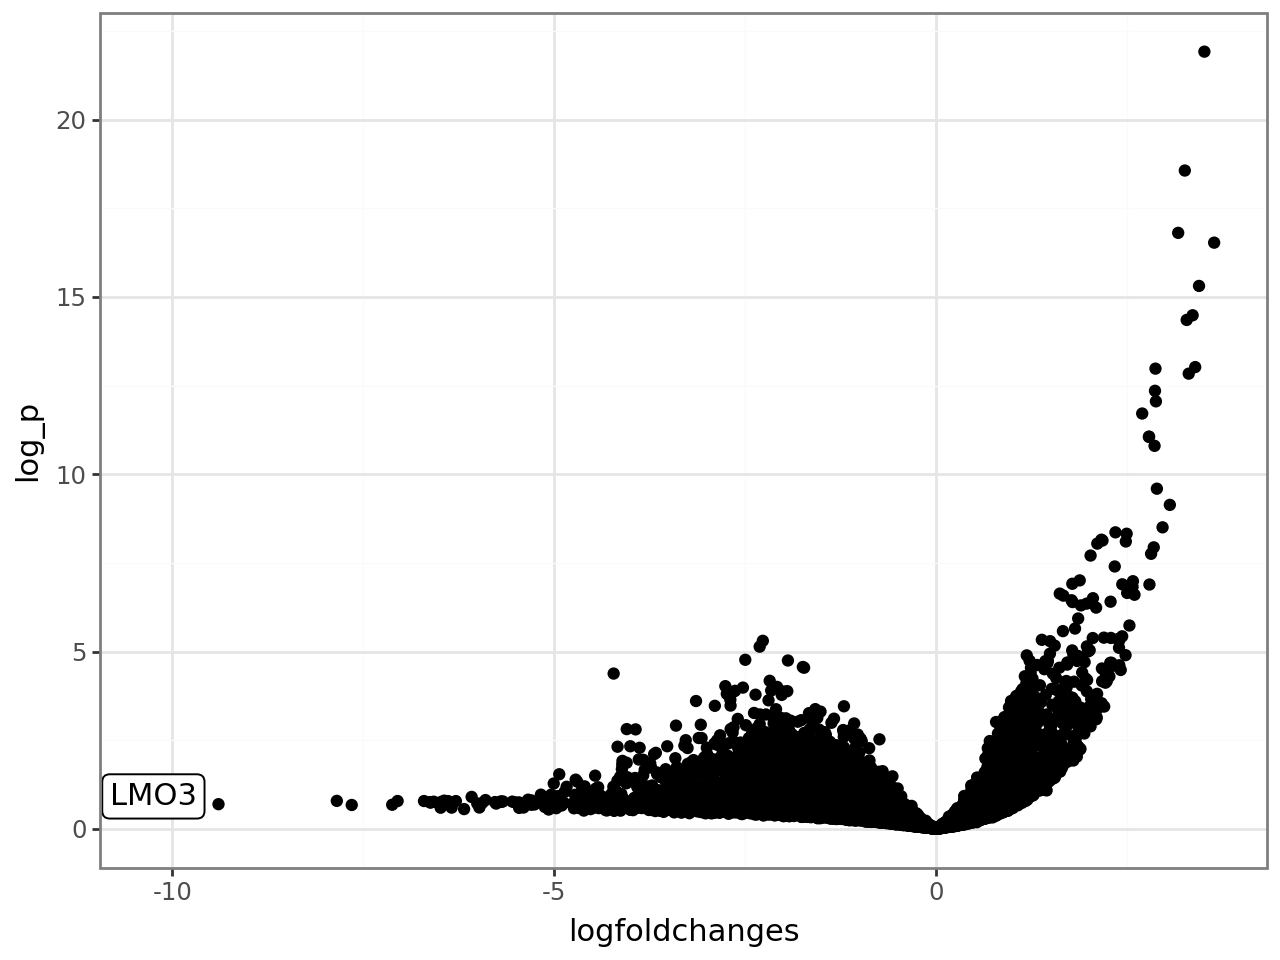

In [245]:
from plotnine import *
degs['label'] = None
degs.loc[(degs['pvals_adj'] < 1) & (np.abs(degs['logfoldchanges']) > 10), 'label'] = degs.loc[(degs['pvals_adj'] < 1) & (np.abs(degs['logfoldchanges']) > 10), 'names']
degs['log_p'] = -np.log10(degs['pvals'])
degs
ggplot(degs, aes(x = 'logfoldchanges', y = 'log_p', label = 'label')) + geom_point() + theme_bw() + geom_label()

In [246]:
degs

,group,names,scores,logfoldchanges,pvals,pvals_adj,label,log_p
144928,Intestinal epithelial cells,PAPPA,13.844087,3.518440,1.203201e-22,4.191535e-20,None,21.919662
144949,Intestinal epithelial cells,ENSOCUG00000022009,10.947116,3.262272,2.712500e-19,6.551591e-17,None,18.566630
144974,Intestinal epithelial cells,TOX4,9.976878,3.175297,1.553231e-17,3.091954e-15,None,16.808764
144951,Intestinal epithelial cells,GPX2,10.905188,3.646526,2.935652e-17,5.597826e-15,None,16.532295
144975,Intestinal epithelial cells,ENSOCUG00000008745,9.974903,3.448254,4.877571e-16,7.960109e-14,None,15.311796
...,...,...,...,...,...,...,...,...
154565,Intestinal epithelial cells,ENSOCUG00000017030,0.001663,0.001446,9.986814e-01,1.000000e+00,None,0.000573
154566,Intestinal epithelial cells,PAFAH1B1,0.001536,0.000579,9.987826e-01,1.000000e+00,None,0.000529
154710,Intestinal epithelial cells,ENSOCUG00000001224,-0.000731,-0.000672,9.994204e-01,1.000000e+00,None,0.000252
154568,Intestinal epithelial cells,GOLIM4,0.000130,0.000075,9.998970e-01,1.000000e+00,None,0.000045


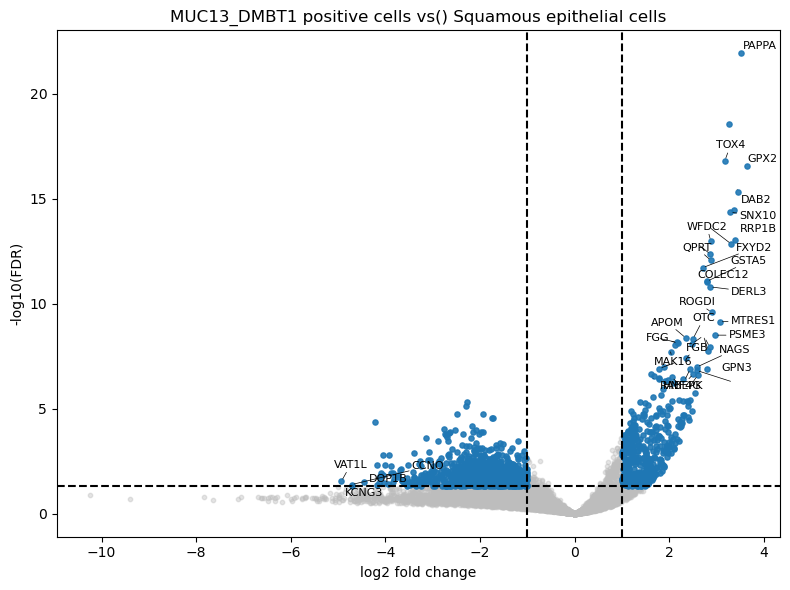

In [247]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

fdr_thresh = 0.05
lfc_thresh = 1.0
label_n = 40

df = degs.copy()
df["log10_fdr"] = -np.log10(df["pvals"].clip(lower=1e-300))

up = (df["pvals"] < fdr_thresh) & (df["logfoldchanges"] > lfc_thresh)
down = (df["pvals"] < fdr_thresh) & (df["logfoldchanges"] < -lfc_thresh)
ns = ~(up | down)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df.loc[ns, "logfoldchanges"], df.loc[ns, "log10_fdr"],
           s=10, color="#BDBDBD", alpha=0.4)

ax.scatter(df.loc[up, "logfoldchanges"], df.loc[up, "log10_fdr"],
           s=14, color="#1F77B4", alpha=0.9)

ax.scatter(df.loc[down, "logfoldchanges"], df.loc[down, "log10_fdr"],
           s=14, color="#1F77B4", alpha=0.9)

# threshold lines
ax.axhline(-np.log10(fdr_thresh), linestyle="--", color="black")
ax.axvline(lfc_thresh, linestyle="--", color="black")
ax.axvline(-lfc_thresh, linestyle="--", color="black")

# labels
label_df = df[up | down].sort_values("pvals_adj").head(label_n)

label_df = pd.concat([label_df, df[down].sort_values("logfoldchanges").head(5)])
label_df.loc[label_df['names'].str.startswith('ENSOC'), 'names'] = None
texts = [
    ax.text(r["logfoldchanges"], r["log10_fdr"], r["names"], fontsize=8)
    for _, r in label_df.iterrows()
]

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5))
ax.set_xlabel("log2 fold change")
ax.set_ylabel("-log10(FDR)")
ax.set_title("MUC13_DMBT1 positive cells vs() Squamous epithelial cells")
plt.tight_layout()
plt.savefig('Muc13_volcano.png')
plt.savefig('Muc13_volcano.pdf')
plt.show()


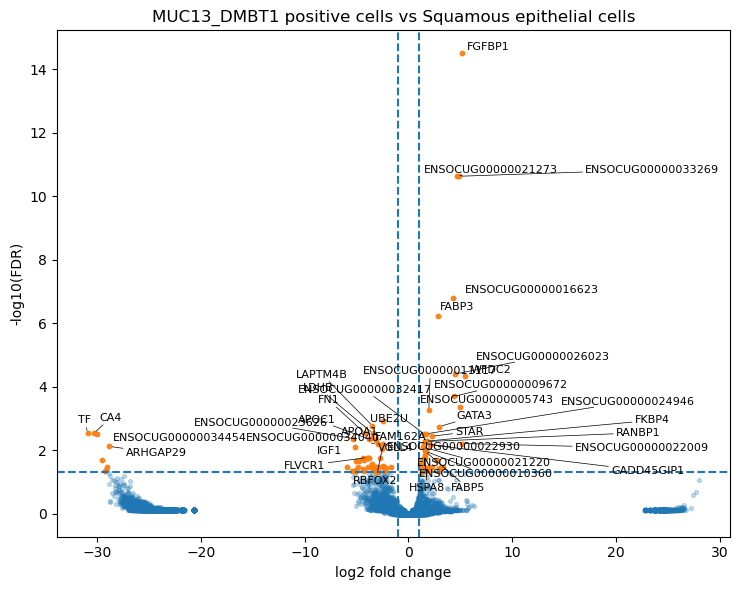

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

fdr_thresh = 0.05
lfc_thresh = 1.0
label_n = 40

df = degs.copy()
df["log10_fdr"] = -np.log10(df["pvals_adj"].clip(lower=1e-300))
df["sig"] = (df["pvals_adj"] < fdr_thresh) & (np.abs(df["logfoldchanges"]) > lfc_thresh)

# choose labels: top N by FDR among significant
label_df = df[df["sig"]].sort_values("pvals_adj").head(label_n)

fig, ax = plt.subplots(figsize=(7.5, 6))

# scatter
ax.scatter(df["logfoldchanges"], df["log10_fdr"], s=8, alpha=0.25)
ax.scatter(df.loc[df["sig"], "logfoldchanges"], df.loc[df["sig"], "log10_fdr"], s=10, alpha=0.9)

# threshold lines
ax.axhline(-np.log10(fdr_thresh), linestyle="--")
ax.axvline(-lfc_thresh, linestyle="--")
ax.axvline(lfc_thresh, linestyle="--")

# labels with repel
texts = []
for _, r in label_df.iterrows():
    texts.append(ax.text(r["logfoldchanges"], r["log10_fdr"], str(r["names"]), fontsize=8))

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", lw=0.5),
)

ax.set_xlabel("log2 fold change")
ax.set_ylabel("-log10(FDR)")
ax.set_title("MUC13_DMBT1 positive cells vs Squamous epithelial cells")
plt.tight_layout()
plt.savefig('Muc13_volcano.png')
plt.savefig('Muc13_volcano.pdf')
plt.show()


In [252]:
rnk = degs[['names', 'scores']].dropna()

rnk['names'] = rnk['names'].astype(str)

# GSEA prerank expects a dataframe with two columns: gene, score
rnk = rnk.rename(columns={'names': "gene",'scores': "score"}).sort_values("score", ascending=True)

pre = gp.prerank(
    rnk=rnk,
    gene_sets='Tabula_Sapiens',
    organism="Human",
    outdir=None,
    seed=0,
    verbose=False,
)

2026-01-30 21:42:38,630 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [102]:
res = pre.res2d.sort_values("FDR q-val")

In [253]:
res.head(20)['Term'].values

array(['RHO GTPases Activate WASPs And WAVEs R-HSA-5663213',
       'Signaling By NOTCH1 R-HSA-1980143',
       'Regulation Of PTEN Gene Transcription R-HSA-8943724',
       'Regulation Of PLK1 Activity At G2/M Transition R-HSA-2565942',
       'Constitutive Signaling By NOTCH1 HD+PEST Domain Mutants R-HSA-2894862',
       'SUMO E3 Ligases SUMOylate Target Proteins R-HSA-3108232',
       'NOTCH1 Intracellular Domain Regulates Transcription R-HSA-2122947',
       'Myogenesis R-HSA-525793',
       'HDMs Demethylate Histones R-HSA-3214842',
       'Factors Involved In Megakaryocyte Development And Platelet Production R-HSA-983231',
       'HDACs Deacetylate Histones R-HSA-3214815',
       'DARPP-32 Events R-HSA-180024',
       'AURKA Activation By TPX2 R-HSA-8854518',
       'Epigenetic Regulation Of Gene Expression R-HSA-212165',
       'Regulation Of Actin Dynamics For Phagocytic Cup Formation R-HSA-2029482',
       'Recruitment Of NuMA To Mitotic Centrosomes R-HSA-380320',
       'Reso

In [104]:
res['NES']= res['NES'].astype(float) 

In [251]:
gp.get_library_name()

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'Carcinogenome',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popul

In [256]:
res.sort_values('NOM p-val').head(50).sort_values('NES').tail()

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
176,prerank,Signaling By Hedgehog R-HSA-5358351,-0.300432,-1.633881,0.0,0.050686,0.502,44/102,20.44%,GSK3B;CUL3;NUMB;DYNC2H1;CUL1;PRKAR2B;ADAM17;CD...
180,prerank,ISG15 Antiviral Mechanism R-HSA-1169408,-0.306706,-1.627173,0.0,0.051523,0.511,24/54,21.10%,TPR;PPM1B;EIF4G3;NUP153;FLNB;NEDD4;NUP205;NUP2...
182,prerank,Potential Therapeutics For SARS R-HSA-9679191,-0.257709,-1.625181,0.0,0.051767,0.515,23/69,11.95%,CUL3;ARID4B;GATAD2B;ROCK2;HDAC2;ARID4A;PHF21A;...
186,prerank,Signaling By NOTCH R-HSA-157118,-0.273382,-1.621772,0.0,0.051783,0.52,35/136,11.58%,PBX1;FBXW7;TBL1XR1;NCOR1;NUMB;HDAC8;HDAC2;MAML...
188,prerank,Rev-mediated Nuclear Export Of HIV RNA R-HSA-1...,-0.356027,-1.616231,0.0,0.053105,0.53,11/29,13.57%,TPR;NUP153;XPO1;NUP205;NUP214;NUP93;NUP98;NUP1...


In [111]:
res[res['NOM p-val'] < 0.05].sort_values('NES')

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,RHO GTPases Activate WASPs And WAVEs R-HSA-566...,-0.631206,-2.940607,0.0,0.0,0.0,18/26,19.29%,ABI2;NCKAP1L;PTK2;CYFIP1;WASF2;NCK1;ACTR2;WASF...
1,prerank,Signaling By NOTCH1 R-HSA-1980143,-0.50954,-2.932101,0.0,0.0,0.0,24/52,11.37%,FBXW7;TBL1XR1;NCOR1;NUMB;HDAC8;HDAC2;MAML3;NBE...
2,prerank,Regulation Of PTEN Gene Transcription R-HSA-89...,-0.539694,-2.929683,0.0,0.0,0.0,31/47,29.70%,GATAD2B;HDAC2;KDM1A;JUN;MTA3;REST;RBBP4;MTOR;R...
3,prerank,Regulation Of PLK1 Activity At G2/M Transition...,-0.473987,-2.873121,0.0,0.0,0.0,32/67,20.44%,PPP1R12A;ALMS1;PPP1R12B;CUL1;PRKAR2B;FBXW11;DY...
4,prerank,Constitutive Signaling By NOTCH1 HD+PEST Domai...,-0.535976,-2.821240,0.0,0.0,0.0,18/40,11.37%,FBXW7;TBL1XR1;NCOR1;HDAC8;HDAC2;MAML3;MIB1;CUL...
...,...,...,...,...,...,...,...,...,...,...
135,prerank,Eukaryotic Translation Elongation R-HSA-156842,0.643257,1.773734,0.001078,0.045729,0.271,18/26,19.98%,RPS3A;RPL18A;RPS5;RPL5;RPS20;RPS16;RPL14;RPS15...
134,prerank,Nonsense Mediated Decay (NMD) Independent Of E...,0.632276,1.777976,0.0,0.053931,0.261,17/29,19.85%,RPS3A;RPL18A;RPS5;RPL5;RPS20;RPS16;RPL14;RPS15...
133,prerank,Selenocysteine Synthesis R-HSA-2408557,0.635895,1.779837,0.0,0.068537,0.25,18/28,19.85%,RPS3A;RPL18A;RPS5;RPL5;RPS20;RPS16;RPL14;RPS15...
132,prerank,Sulfur Amino Acid Metabolism R-HSA-1614635,0.706004,1.786535,0.0,0.092693,0.23,7/15,14.19%,TXN2;GADL1;MTRR;CSAD;SUOX;SQOR;ADI1


In [72]:
res.head(15).assign(Term=lambda d: pd.Categorical(d["Term"],
                                            categories=d.sort_values("NES")["Term"]))

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Translation R-HSA-72766,0.625516,2.607496,0.0,0.0,0.0,73/169,7.22%,GADD45GIP1;RPS5;RPL18A;EEF1E1;MRPL52;EIF3D;YAR...
19,prerank,rRNA Processing R-HSA-72312,0.625791,2.345021,0.0,0.0,0.0,69/111,15.93%,RPS5;RPL18A;RPL14;RPS16;RPS12;RPS3A;RPLP1;RPLP...
18,prerank,Major Pathway Of rRNA Processing In Nucleolus ...,0.635237,2.349537,0.0,0.0,0.0,60/98,15.93%,RPS5;RPL18A;RPL14;RPS16;RPS12;RPS3A;RPLP1;RPLP...
17,prerank,Mitochondrial Translation Termination R-HSA-54...,0.689713,2.363005,0.0,0.0,0.0,25/50,7.22%,GADD45GIP1;MRPL52;MRPL33;MRPS26;MRPS11;MRPS15;...
16,prerank,"Formation Of Ternary Complex, And Subsequently...",0.831837,2.363193,0.0,0.0,0.0,16/23,7.17%,RPS5;EIF3D;RPS16;RPS12;RPS3A;RPS15;RPS20;RPS28...
15,prerank,Viral mRNA Translation R-HSA-192823,0.795714,2.376389,0.0,0.0,0.0,22/30,7.14%,RPS5;RPL18A;RPL14;RPS16;RPS12;RPS3A;RPLP1;RPLP...
14,prerank,rRNA Processing In Nucleus And Cytosol R-HSA-8...,0.64881,2.384201,0.0,0.0,0.0,48/104,7.14%,RPS5;RPL18A;RPL14;RPS16;RPS12;RPS3A;RPLP1;RPLP...
13,prerank,Response Of EIF2AK4 (GCN2) To Amino Acid Defic...,0.760588,2.406814,0.0,0.0,0.0,19/35,1.74%,RPS5;CEBPB;RPL18A;RPL14;RPS16;RPS12;RPS3A;RPLP...
12,prerank,Mitochondrial Translation R-HSA-5368287,0.7008,2.421625,0.0,0.0,0.0,29/56,7.22%,GADD45GIP1;MRPL52;MRPL33;MRPS26;MRPS11;MRPS15;...
11,prerank,Mitochondrial Translation Initiation R-HSA-536...,0.707434,2.421884,0.0,0.0,0.0,26/51,7.22%,GADD45GIP1;MRPL52;MRPL33;MRPS26;MRPS11;MRPS15;...


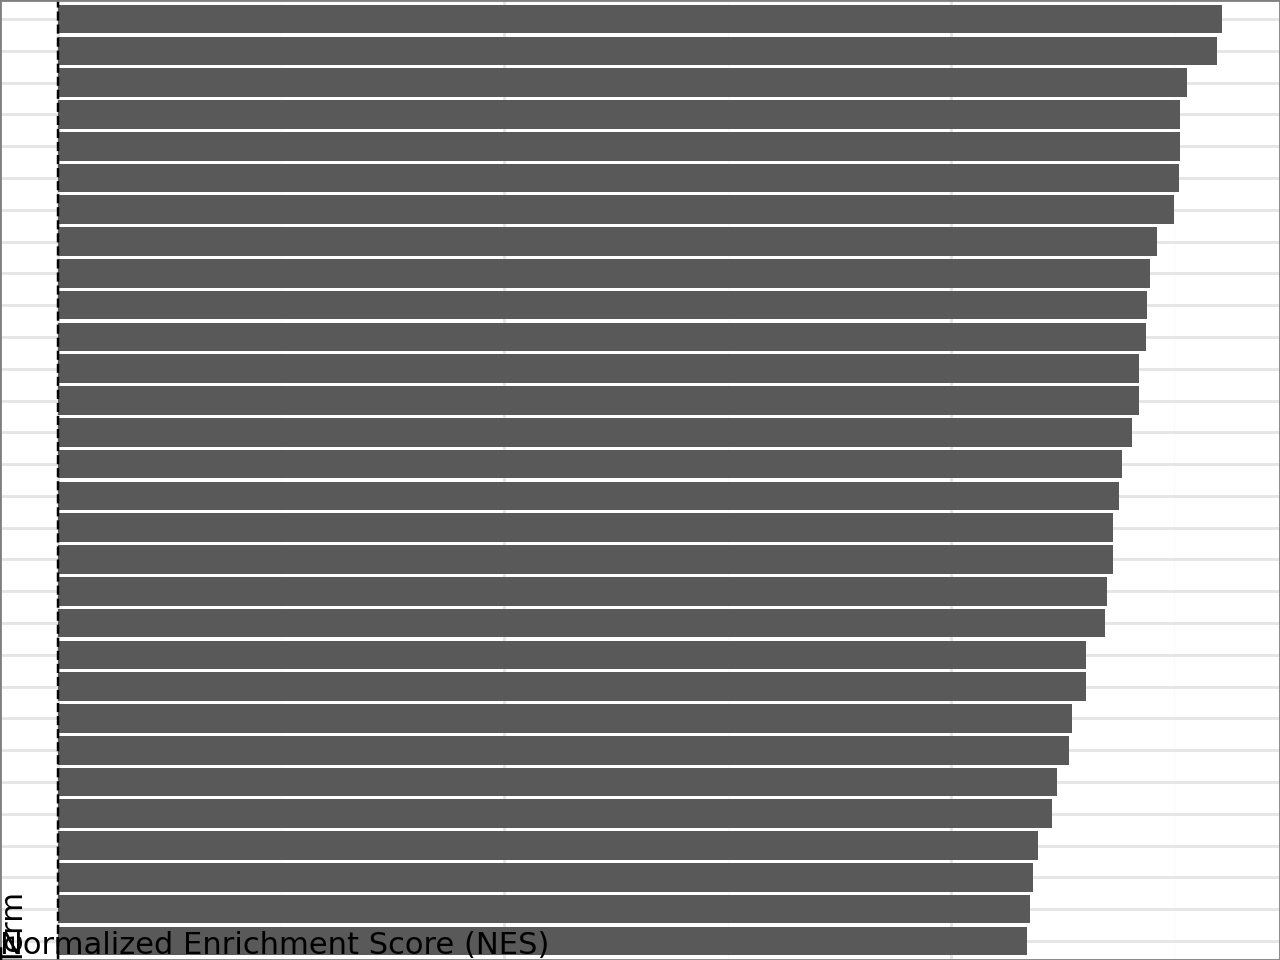

In [73]:
from plotnine import *
import pandas as pd
(
    res.head(30)
      .assign(Term=lambda d: pd.Categorical(d["Term"],
                                            categories=d.sort_values("NES")["Term"]))
      >> ggplot(aes(x="Term", y="NES"))
      + geom_col()
      + coord_flip()
      + geom_hline(yintercept=0, linetype="dashed")
      + labs(
          x=None,
          y="Normalized Enrichment Score (NES)",
          title="Reactome pathway enrichment"
      )
      + theme_bw()
)


In [246]:
res['Term'] = res['Term'].str.split(' R-HS').str[0]

In [2]:
import scanpy as sc

In [7]:
adata = sc.read_h5ad('/home/cachris/data/tf_embeddings/fetal_atlas/Cerebellum_gene_count.RDS.h5ad')

In [9]:
adata.var

,gene_id,ensembl_id
ENSG00000223972.4,ENSG00000223972.4,ENSG00000223972.4
ENSG00000227232.4,ENSG00000227232.4,ENSG00000227232.4
ENSG00000243485.2,ENSG00000243485.2,ENSG00000243485.2
ENSG00000237613.2,ENSG00000237613.2,ENSG00000237613.2
ENSG00000268020.2,ENSG00000268020.2,ENSG00000268020.2
...,...,...
ENSG00000240779.1,ENSG00000240779.1,ENSG00000240779.1
ENSG00000244656.1,ENSG00000244656.1,ENSG00000244656.1
ENSG00000263760.1,ENSG00000263760.1,ENSG00000263760.1
ENSG00000222670.2,ENSG00000222670.2,ENSG00000222670.2
